# File 05 — Feature Analysis: Tại sao model đúng / sai?

Mục tiêu: Dùng kết quả predict từ 2 model (XLM-RoBERTa và Hybrid) để phân tích xem 4 feature ngôn ngữ có liên quan thế nào đến việc model phân loại đúng hay sai.

**Cấu trúc:**
- Phần 1 — Tính 4 feature trên test set
- Phần 2 — Predict bằng 2 model, gán nhãn đúng/sai
- Phần 3 — So sánh feature giữa nhóm đúng và sai
- Phần 4 — Phân tích lỗi: FP vs FN
- Phần 5 — Kết luận: Cohen's d effect size

In [4]:
!pip install matplotlib seaborn scipy pandas torch transformers sentencepiece langdetect underthesea tqdm -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from collections import Counter
from matplotlib.patches import Patch
import re
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from langdetect import detect_langs, DetectorFactory, LangDetectException
from underthesea import word_tokenize
from tqdm import tqdm

DetectorFactory.seed = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

XLM_DIR = '/kaggle/input/datasets/minhbodoi/xlmroberta-model'
RO_DIR  = '/kaggle/input/datasets/minhbodoi/hybrid-models/roberta'
PH_DIR  = '/kaggle/input/datasets/minhbodoi/hybrid-models/phobert'

MAX_LEN        = 128
BATCH_SIZE     = 32
LANG_THRESHOLD = 0.8
FEATURES       = ['burstiness', 'entropy', 'ttr', 'avg_sent_len']

Device: cuda


## Phần 1 — Tính 4 feature ngôn ngữ

In [6]:
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

def get_sentences(text):
    return [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

def calc_burstiness(text):
    """(std - mean) / (std + mean) tần suất từ. Cao → bùng nổ từ vựng (human)."""
    words = tokenize(text)
    if len(words) < 10: return np.nan
    freq = list(Counter(words).values())
    mu, sigma = np.mean(freq), np.std(freq)
    return (sigma - mu) / (sigma + mu) if (sigma + mu) != 0 else 0

def calc_entropy(text):
    """Shannon entropy phân phối từ. Thấp → đều đặn (AI)."""
    from scipy.stats import entropy as scipy_entropy
    words = tokenize(text)
    if len(words) < 10: return np.nan
    freq = list(Counter(words).values())
    return scipy_entropy(np.array(freq) / sum(freq))

def calc_ttr(text):
    """Type-Token Ratio = unique / total. Thấp → lặp từ nhiều (AI)."""
    words = tokenize(text)
    return len(set(words)) / len(words) if words else np.nan

def calc_avg_sent_len(text):
    """Độ dài câu trung bình. AI thường có câu dài và đều hơn."""
    sents = get_sentences(text)
    if not sents: return np.nan
    return np.mean([len(tokenize(s)) for s in sents])

# Load test set
test_en_df = pd.read_csv('/kaggle/input/datasets/minhbodoi/faidset-processed/test_en.csv', encoding='utf-8-sig')
test_vi_df = pd.read_csv('/kaggle/input/datasets/minhbodoi/faidset-processed/test_vi.csv', encoding='utf-8-sig')
df = pd.concat([test_en_df, test_vi_df]).reset_index(drop=True)
print(f'Test set: {len(df):,} records')

print('Đang tính 4 feature (vài phút)...')
df['burstiness']   = df['text'].apply(calc_burstiness)
df['entropy']      = df['text'].apply(calc_entropy)
df['ttr']          = df['text'].apply(calc_ttr)
df['avg_sent_len'] = df['text'].apply(calc_avg_sent_len)
df['label_str']    = df['label'].map({0: 'Human', 1: 'AI'})
print('Xong!')
df[['burstiness','entropy','ttr','avg_sent_len']].describe().round(3)

Test set: 126,179 records
Đang tính 4 feature (vài phút)...
Xong!


,burstiness,entropy,ttr,avg_sent_len
count,126091.000,126091.000,126179.000,126179.000
mean,-0.142,4.194,0.671,18.534
std,0.257,0.728,0.163,12.055
min,-1.000,1.216,0.027,1.278
25%,-0.326,3.615,0.571,12.684
50%,-0.141,4.232,0.681,17.500
75%,0.049,4.693,0.792,22.250
max,0.723,6.829,1.000,1039.000


## Phần 2 — Predict bằng 2 model, gán nhãn đúng/sai

Gán thêm 2 cột:
- `correct`: 1 nếu model đoán đúng, 0 nếu sai
- `error_type`: `Correct` / `FP (Human→AI)` / `FN (AI→Human)`

In [7]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts   = df['text'].tolist()
        self.labels  = df['label'].tolist()
        self.tok     = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], max_length=self.max_len,
                       padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'label':          torch.tensor(self.labels[idx], dtype=torch.long)}

# Model 1: XLM-RoBERTa
print('Loading XLM-RoBERTa...')
tok_xlm   = AutoTokenizer.from_pretrained(XLM_DIR)
model_xlm = AutoModelForSequenceClassification.from_pretrained(XLM_DIR).to(device)
model_xlm.eval()

preds_xlm = []
with torch.no_grad():
    for batch in tqdm(DataLoader(TextDataset(df, tok_xlm, MAX_LEN), batch_size=BATCH_SIZE),
                      desc='XLM-RoBERTa'):
        out = model_xlm(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
        preds_xlm.extend(out.logits.argmax(-1).cpu().numpy())

df['pred_xlm']       = preds_xlm
df['correct_xlm']    = (df['pred_xlm'] == df['label']).astype(int)
df['error_type_xlm'] = df.apply(
    lambda r: 'FP (Human→AI)' if (r['label']==0 and r['pred_xlm']==1)
    else ('FN (AI→Human)' if (r['label']==1 and r['pred_xlm']==0) else 'Correct'), axis=1)

print('XLM-RoBERTa xong')
print(df['error_type_xlm'].value_counts().to_string())

Loading XLM-RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLM-RoBERTa: 100%|██████████| 3944/3944 [17:29<00:00,  3.76it/s]


XLM-RoBERTa xong
error_type_xlm
Correct          94148
FP (Human→AI)    29449
FN (AI→Human)     2582


In [8]:
# Model 2: Hybrid
print('Loading Hybrid (RoBERTa + PhoBERT)...')
tok_ro   = AutoTokenizer.from_pretrained(RO_DIR)
model_ro = AutoModelForSequenceClassification.from_pretrained(RO_DIR).to(device)
tok_ph   = AutoTokenizer.from_pretrained(PH_DIR)
model_ph = AutoModelForSequenceClassification.from_pretrained(PH_DIR).to(device)
model_ro.eval(); model_ph.eval()

def detect_language(text):
    try:
        results = detect_langs(text[:500])
        top = results[0]
        return (top.lang if top.lang in ['en','vi'] else 'other'), top.prob
    except LangDetectException:
        return 'other', 0.0

def predict_proba(text, model, tokenizer, segment=False):
    if segment: text = word_tokenize(text, format='text')
    enc = tokenizer(text, max_length=MAX_LEN, padding='max_length',
                    truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(input_ids=enc['input_ids'].to(device),
                       attention_mask=enc['attention_mask'].to(device)).logits
    return F.softmax(logits, dim=-1)[0][1].item()

def hybrid_predict(text):
    lang, prob = detect_language(text)
    if prob >= LANG_THRESHOLD:
        if lang == 'en':   p_ai = predict_proba(text, model_ro, tok_ro)
        elif lang == 'vi': p_ai = predict_proba(text, model_ph, tok_ph, segment=True)
        else: p_ai = (predict_proba(text,model_ro,tok_ro)+predict_proba(text,model_ph,tok_ph,True))/2
    else:
        p_ai = (predict_proba(text,model_ro,tok_ro)+predict_proba(text,model_ph,tok_ph,True))/2
    return 1 if p_ai >= 0.5 else 0

preds_hybrid = [hybrid_predict(t) for t in tqdm(df['text'].tolist(), desc='Hybrid')]
df['pred_hybrid']       = preds_hybrid
df['correct_hybrid']    = (df['pred_hybrid'] == df['label']).astype(int)
df['error_type_hybrid'] = df.apply(
    lambda r: 'FP (Human→AI)' if (r['label']==0 and r['pred_hybrid']==1)
    else ('FN (AI→Human)' if (r['label']==1 and r['pred_hybrid']==0) else 'Correct'), axis=1)

print('Hybrid xong')
print(df['error_type_hybrid'].value_counts().to_string())

Loading Hybrid (RoBERTa + PhoBERT)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Hybrid: 100%|██████████| 126179/126179 [27:11<00:00, 77.35it/s]


Hybrid xong
error_type_hybrid
Correct          96168
FP (Human→AI)    27313
FN (AI→Human)     2698


## Phần 3 — Boxplot: feature của nhóm đúng vs sai

Xanh = đoán đúng, Cam = đoán sai. Tiêu đề ghi kết quả Mann-Whitney U test:
`***` p<0.001 · `**` p<0.01 · `*` p<0.05 · `ns` không có ý nghĩa thống kê.

/tmp/ipykernel_58/212926112.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([correct, wrong], labels=['Đúng','Sai'],
/tmp/ipykernel_58/212926112.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([correct, wrong], labels=['Đúng','Sai'],
/tmp/ipykernel_58/212926112.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([correct, wrong], labels=['Đúng','Sai'],
/tmp/ipykernel_58/212926112.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = 

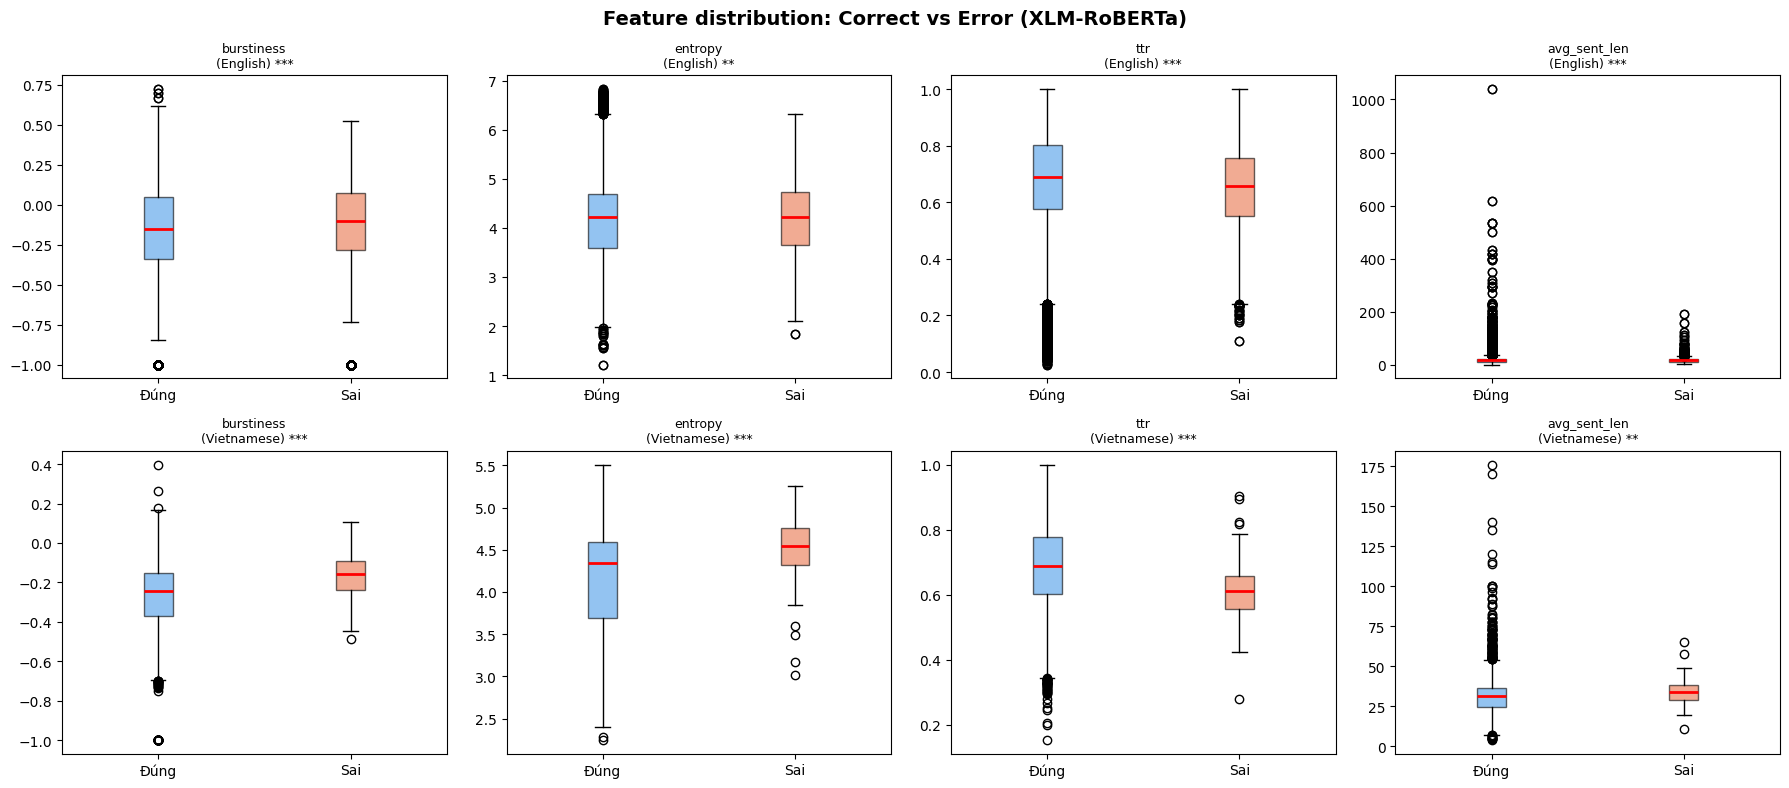

Saved: feature_vs_correctness.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature distribution: Correct vs Error (XLM-RoBERTa)',
             fontsize=14, fontweight='bold')

for row, (lang, lang_name) in enumerate({'en':'English','vi':'Vietnamese'}.items()):
    sub = df[df['language'] == lang].dropna()
    for col, feat in enumerate(FEATURES):
        ax = axes[row][col]
        correct = sub[sub['correct_xlm'] == 1][feat].dropna()
        wrong   = sub[sub['correct_xlm'] == 0][feat].dropna()
        bp = ax.boxplot([correct, wrong], labels=['Đúng','Sai'],
                        patch_artist=True,
                        medianprops=dict(color='red', linewidth=2))
        bp['boxes'][0].set(facecolor='#4C9BE8', alpha=0.6)
        bp['boxes'][1].set(facecolor='#E8734C', alpha=0.6)
        if len(correct) > 10 and len(wrong) > 10:
            _, p = mannwhitneyu(correct, wrong, alternative='two-sided')
            sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
            ax.set_title(f'{feat}\n({lang_name}) {sig}', fontsize=9)
        else:
            ax.set_title(f'{feat}\n({lang_name})', fontsize=9)
        ax.set_xlabel('')

plt.tight_layout()
plt.savefig('feature_vs_correctness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_vs_correctness.png')

## Phần 4 — Phân tích lỗi: FP vs FN

- **FP (False Positive)**: văn bản Human bị đoán là AI — feature của chúng có gì đặc biệt?
- **FN (False Negative)**: văn bản AI bị đoán là Human — tương tự?

Nếu FP có burstiness thấp hơn Human đúng → model bị đánh lừa bởi những văn bản Human viết "đều" như AI.

In [10]:
sub_en = df[df['language'] == 'en'].dropna()

print('PHÂN TÍCH LỖI THEO FEATURE — tiếng Anh (XLM-RoBERTa)')
print('='*62)
for feat in FEATURES:
    correct = sub_en[sub_en['error_type_xlm'] == 'Correct'][feat]
    fp      = sub_en[sub_en['error_type_xlm'] == 'FP (Human→AI)'][feat]
    fn      = sub_en[sub_en['error_type_xlm'] == 'FN (AI→Human)'][feat]
    print(f'\n[{feat}]')
    print(f'  Correct  — mean: {correct.mean():.4f}, median: {correct.median():.4f}')
    print(f'  FP       — mean: {fp.mean():.4f},     median: {fp.median():.4f}  (Human bị nhầm → AI)')
    print(f'  FN       — mean: {fn.mean():.4f},     median: {fn.median():.4f}  (AI bị nhầm → Human)')
    correct_human = sub_en[(sub_en['label']==0) & (sub_en['error_type_xlm']=='Correct')][feat]
    if len(correct_human.dropna()) > 10 and len(fp.dropna()) > 10:
        _, p = mannwhitneyu(correct_human.dropna(), fp.dropna(), alternative='two-sided')
        print(f"  FP vs Correct-Human: p={p:.4f} {'← có ý nghĩa' if p<0.05 else '(không đáng kể)'}")

PHÂN TÍCH LỖI THEO FEATURE — tiếng Anh (XLM-RoBERTa)

[burstiness]
  Correct  — mean: -0.1479, median: -0.1490
  FP       — mean: -0.1007,     median: -0.0894  (Human bị nhầm → AI)
  FN       — mean: -0.2589,     median: -0.3131  (AI bị nhầm → Human)
  FP vs Correct-Human: p=0.0000 ← có ý nghĩa

[entropy]
  Correct  — mean: 4.1973, median: 4.2314
  FP       — mean: 4.2284,     median: 4.2574  (Human bị nhầm → AI)
  FN       — mean: 3.7219,     median: 3.4870  (AI bị nhầm → Human)
  FP vs Correct-Human: p=0.0000 ← có ý nghĩa

[ttr]
  Correct  — mean: 0.6750, median: 0.6906
  FP       — mean: 0.6492,     median: 0.6471  (Human bị nhầm → AI)
  FN       — mean: 0.7341,     median: 0.7750  (AI bị nhầm → Human)
  FP vs Correct-Human: p=0.0000 ← có ý nghĩa

[avg_sent_len]
  Correct  — mean: 18.4208, median: 17.3111
  FP       — mean: 17.7149,     median: 17.5000  (Human bị nhầm → AI)
  FN       — mean: 15.5455,     median: 14.7143  (AI bị nhầm → Human)
  FP vs Correct-Human: p=0.0000 ← có ý n

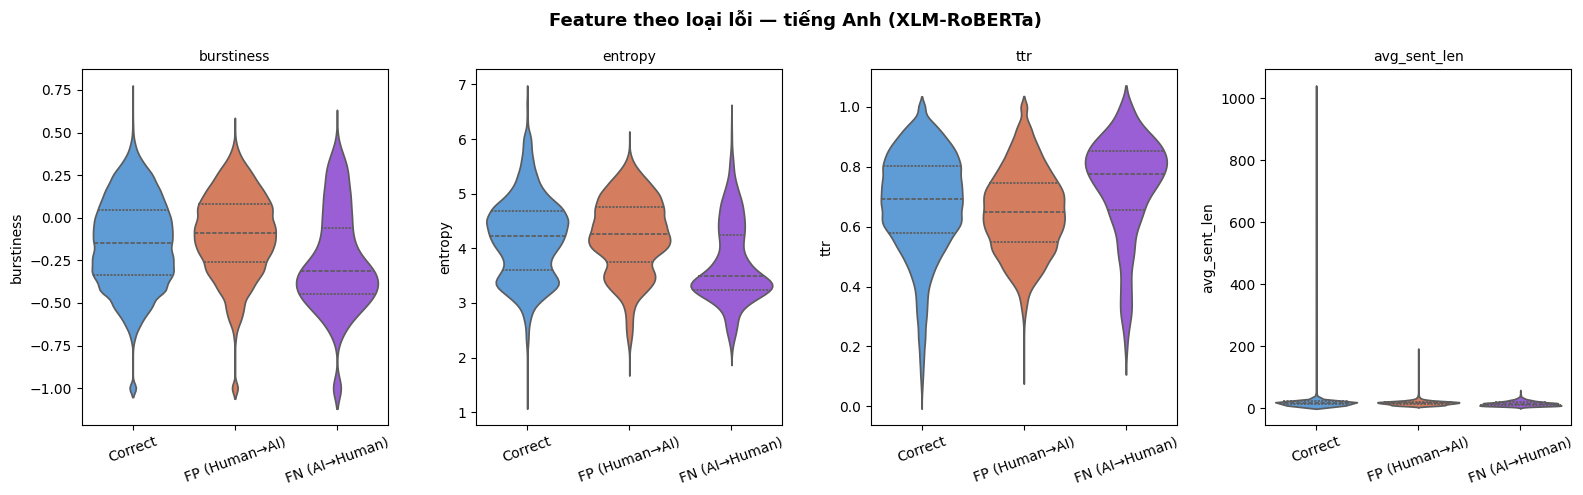

Saved: feature_error_type.png


In [11]:
# Violin plot: 3 nhóm Correct / FP / FN
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Feature theo loại lỗi — tiếng Anh (XLM-RoBERTa)',
             fontsize=13, fontweight='bold')

palette = {'Correct':'#4C9BE8','FP (Human→AI)':'#E8734C','FN (AI→Human)':'#9B4CE8'}
order   = ['Correct','FP (Human→AI)','FN (AI→Human)']
sub_en_plot = sub_en[sub_en['error_type_xlm'].isin(order)].copy()

for i, feat in enumerate(FEATURES):
    sns.violinplot(data=sub_en_plot, x='error_type_xlm', y=feat,
                   hue='error_type_xlm', palette=palette, ax=axes[i],
                   inner='quartile', legend=False, order=order)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.savefig('feature_error_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_error_type.png')

## Phần 5 — Kết luận: Cohen's d — feature nào ảnh hưởng nhiều nhất?

**Cohen's d** đo độ lớn của sự khác biệt giữa nhóm đoán đúng và sai:
- d < 0.2: nhỏ (feature gần như không liên quan đến lỗi)
- 0.2 ≤ d < 0.5: trung bình
- d ≥ 0.5: lớn — feature này liên quan rõ ràng đến lỗi model

Màu **cam** = có ý nghĩa thống kê (p < 0.05). Màu **xám** = không.

In [12]:
def cohens_d(a, b):
    a, b = a.dropna(), b.dropna()
    pooled = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return abs(a.mean() - b.mean()) / pooled if pooled > 0 else 0

results = []
for lang in ['en', 'vi']:
    sub = df[df['language'] == lang].dropna()
    for feat in FEATURES:
        correct = sub[sub['correct_xlm'] == 1][feat]
        wrong   = sub[sub['correct_xlm'] == 0][feat]
        d = cohens_d(correct, wrong)
        if len(correct.dropna()) > 10 and len(wrong.dropna()) > 10:
            _, p = mannwhitneyu(correct.dropna(), wrong.dropna(), alternative='two-sided')
        else:
            p = 1.0
        results.append({'Language': lang.upper(), 'Feature': feat,
                        "Cohen's d": round(d,4), 'p-value': round(p,6),
                        'Significant': 'YES' if p < 0.05 else 'NO'})

df_result = pd.DataFrame(results).sort_values(['Language',"Cohen's d"], ascending=[True,False])
print(df_result.to_string(index=False))

Language      Feature  Cohen's d  p-value Significant
      EN   burstiness     0.1351 0.000000         YES
      EN          ttr     0.1203 0.000000         YES
      EN avg_sent_len     0.0836 0.000000         YES
      EN      entropy     0.0135 0.004499         YES
      VI      entropy     0.6928 0.000004         YES
      VI   burstiness     0.6848 0.000003         YES
      VI          ttr     0.5576 0.000008         YES
      VI avg_sent_len     0.2646 0.009458         YES


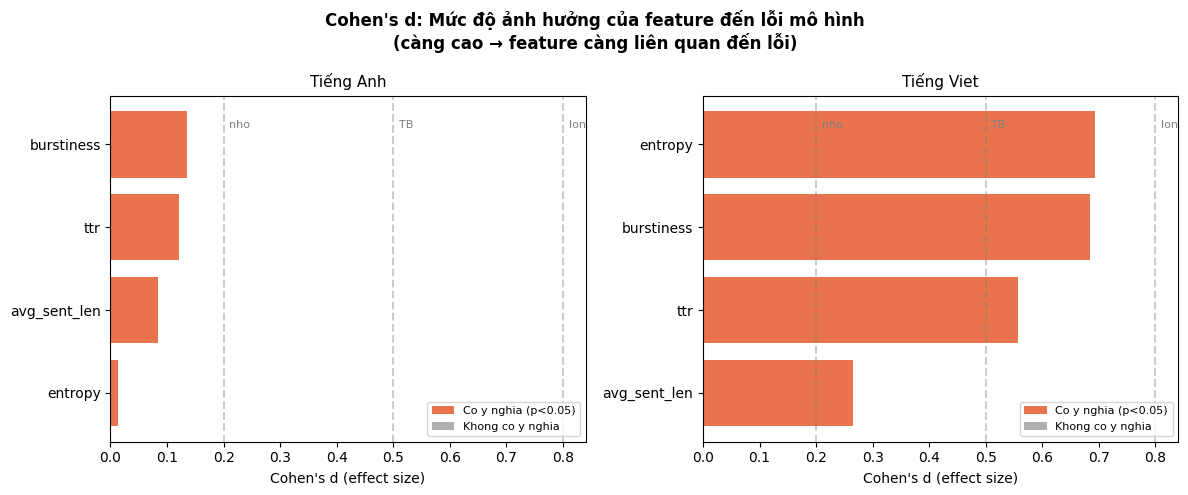

Saved: feature_effect_size.png

 Done! Output: feature_vs_correctness.png, feature_error_type.png, feature_effect_size.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Cohen's d: Mức độ ảnh hưởng của feature đến lỗi mô hình\n"
             '(càng cao → feature càng liên quan đến lỗi)',
             fontsize=12, fontweight='bold')

for i, lang in enumerate(['EN', 'VI']):
    sub_r  = df_result[df_result['Language'] == lang].sort_values("Cohen's d", ascending=True)
    colors = ['#E8734C' if s == 'YES' else '#B0B0B0' for s in sub_r['Significant']]
    axes[i].barh(sub_r['Feature'], sub_r["Cohen's d"], color=colors)
    axes[i].set_title(f"Tiếng {'Anh' if lang=='EN' else 'Viet'}", fontsize=11)
    axes[i].set_xlabel("Cohen's d (effect size)")
    for v, lbl in [(0.2,'nho'),(0.5,'TB'),(0.8,'lon')]:
        axes[i].axvline(v, color='gray', linestyle='--', alpha=0.4)
        axes[i].text(v+0.01, len(FEATURES)-0.8, lbl, fontsize=8, color='gray')
    legend_els = [Patch(facecolor='#E8734C', label='Co y nghia (p<0.05)'),
                  Patch(facecolor='#B0B0B0', label='Khong co y nghia')]
    axes[i].legend(handles=legend_els, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('feature_effect_size.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_effect_size.png')
print('\n Done! Output: feature_vs_correctness.png, feature_error_type.png, feature_effect_size.png')